# Clase 5: Regresión polinomial y Ridge

La idea importante no es que Ridge "baja las betas".

La idea importante es:

> Un modelo flexible puede aprender patrones reales, pero también puede perseguir ruido.  
> Ridge controla esa flexibilidad castigando coeficientes grandes.

En esta clase vamos a separar dos preguntas:

1. ¿Por qué necesitamos modelos más flexibles que una recta?
2. ¿Por qué necesitamos regularización cuando el modelo se vuelve muy flexible?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')


## Parte A: una historia visual

Primero usamos datos simulados porque aquí sí conocemos la relación real.

Eso nos permite distinguir tres cosas que en datos reales se mezclan:

- la señal verdadera,
- el ruido de los datos,
- y el sobreajuste del modelo.


In [2]:
np.random.seed(1)

n = 18
X_train = np.linspace(0, 10, n).reshape(-1, 1)

def relacion_real(x):
    return 40 + 6 * x + 22 * np.sin(0.9 * x)

# Observamos la relación real con ruido.
y_train = relacion_real(X_train.ravel()) + np.random.normal(0, 4, n)

# Esta malla representa muchos puntos de la relación real, sin ruido.
# La usamos para evaluar si el modelo aprendió la forma general.
x_grid = np.linspace(0, 10, 500).reshape(-1, 1)
y_grid_real = relacion_real(x_grid.ravel())


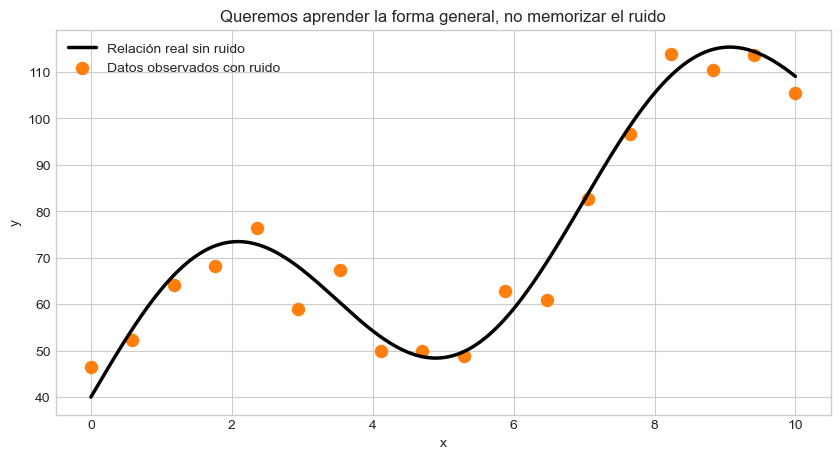

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(x_grid, y_grid_real, color='black', linewidth=2.5, label='Relación real sin ruido')
plt.scatter(X_train, y_train, s=75, color='tab:orange', label='Datos observados con ruido')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Queremos aprender la forma general, no memorizar el ruido')
plt.legend()
plt.show()


## 1. Tres modelos

Usaremos los mismos 18 puntos para comparar:

- Regresión lineal: poca flexibilidad.
- Polinomio grado 15: muchísima flexibilidad.
- Polinomio grado 15 + Ridge: mucha flexibilidad, pero con control.


In [4]:
grado = 15

modelo_lineal = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

modelo_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=grado, include_bias=False)),
    ('model', LinearRegression())
])

modelo_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=grado, include_bias=False)),
    ('model', Ridge(alpha=20))
])

modelos = {
    'Lineal': modelo_lineal,
    'Polinomio grado 15': modelo_poly,
    'Polinomio grado 15 + Ridge': modelo_ridge,
}

for modelo in modelos.values():
    modelo.fit(X_train, y_train)


In [5]:
metricas = []

for nombre, modelo in modelos.items():
    pred_entrenamiento = modelo.predict(X_train)
    pred_curva_real = modelo.predict(x_grid)

    metricas.append({
        'modelo': nombre,
        'R2 en datos observados': r2_score(y_train, pred_entrenamiento),
        'R2 contra relación real': r2_score(y_grid_real, pred_curva_real),
        'RMSE contra relación real': np.sqrt(mean_squared_error(y_grid_real, pred_curva_real)),
    })

pd.DataFrame(metricas).round(3)


,modelo,R2 en datos observados,R2 contra relación real,RMSE contra relación real
0,Lineal,0.602,0.567,15.186
1,Polinomio grado 15,0.989,-11.171,80.467
2,Polinomio grado 15 + Ridge,0.753,0.749,11.565


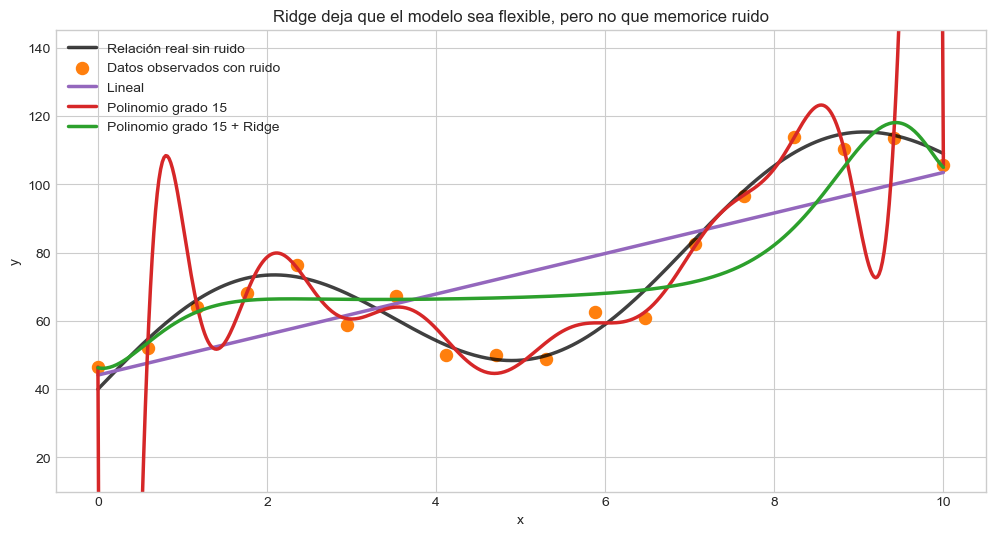

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(x_grid, y_grid_real, color='black', linewidth=2.5, alpha=0.75, label='Relación real sin ruido')
plt.scatter(X_train, y_train, s=75, color='tab:orange', label='Datos observados con ruido')

colores = {
    'Lineal': 'tab:purple',
    'Polinomio grado 15': 'tab:red',
    'Polinomio grado 15 + Ridge': 'tab:green',
}

for nombre, modelo in modelos.items():
    plt.plot(x_grid, modelo.predict(x_grid), linewidth=2.5, color=colores[nombre], label=nombre)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Ridge deja que el modelo sea flexible, pero no que memorice ruido')
plt.ylim(y_grid_real.min() - 30, y_grid_real.max() + 30)
plt.legend()
plt.show()


## 2. ¿Qué cambia cuando cambiamos `alpha`?

`alpha` es la fuerza de la regularización.

- Si `alpha` es muy pequeño, Ridge casi no castiga nada.
- Si `alpha` es muy grande, el modelo se vuelve demasiado conservador.
- En medio suele estar el mejor balance.


In [7]:
alphas = np.logspace(-4, 3, 45)
resultados = []

for alpha in alphas:
    modelo = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=grado, include_bias=False)),
        ('model', Ridge(alpha=alpha))
    ])
    modelo.fit(X_train, y_train)
    coefs = modelo.named_steps['model'].coef_

    resultados.append({
        'alpha': alpha,
        'R2 en datos observados': r2_score(y_train, modelo.predict(X_train)),
        'R2 contra relación real': r2_score(y_grid_real, modelo.predict(x_grid)),
        'tamaño_coeficientes': np.sqrt(np.sum(coefs ** 2)),
    })

resultados = pd.DataFrame(resultados)
resultados.head()


,alpha,R2 en datos observados,R2 contra relación real,tamaño_coeficientes
0,0.000100,0.975502,0.938521,145.727364
1,0.000144,0.975422,0.940890,120.875675
2,0.000208,0.975356,0.943365,103.870874
3,0.000300,0.975295,0.945938,91.629372
4,0.000433,0.975237,0.948561,82.448191


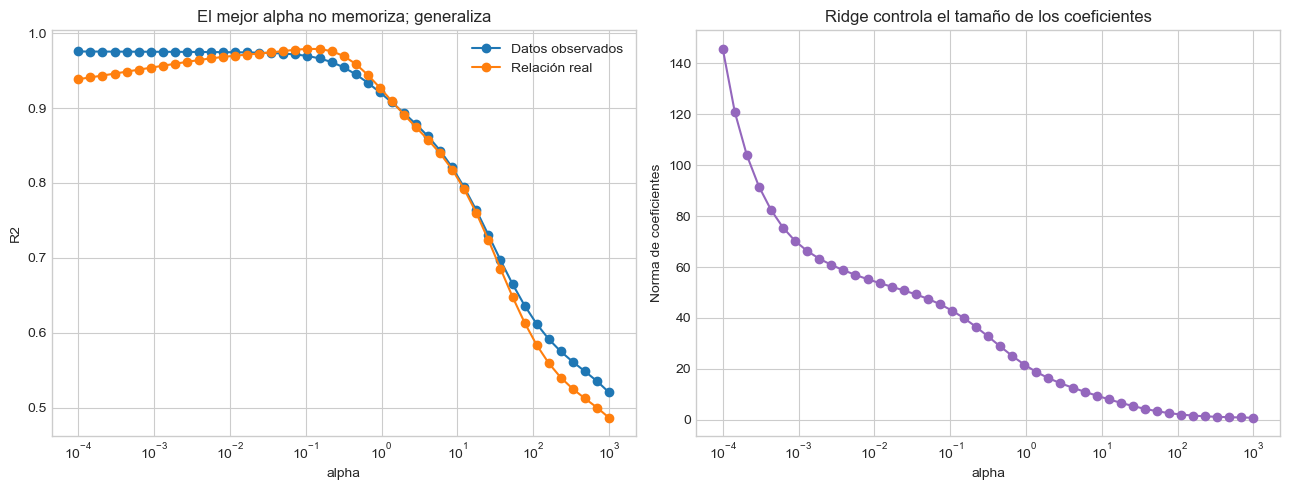

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(resultados['alpha'], resultados['R2 en datos observados'], marker='o', label='Datos observados')
axes[0].plot(resultados['alpha'], resultados['R2 contra relación real'], marker='o', label='Relación real')
axes[0].set_xscale('log')
axes[0].set_xlabel('alpha')
axes[0].set_ylabel('R2')
axes[0].set_title('El mejor alpha no memoriza; generaliza')
axes[0].legend()

axes[1].plot(resultados['alpha'], resultados['tamaño_coeficientes'], marker='o', color='tab:purple')
axes[1].set_xscale('log')
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('Norma de coeficientes')
axes[1].set_title('Ridge controla el tamaño de los coeficientes')

plt.tight_layout()
plt.show()


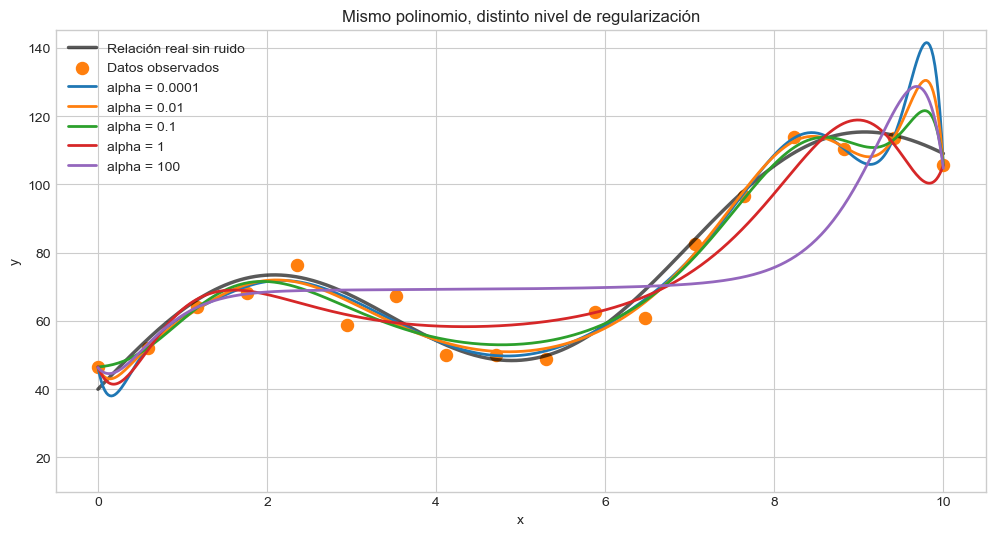

In [9]:
alphas_a_mostrar = [0.0001, 0.01, 0.1, 1, 100]

plt.figure(figsize=(12, 6))
plt.plot(x_grid, y_grid_real, color='black', linewidth=2.5, alpha=0.65, label='Relación real sin ruido')
plt.scatter(X_train, y_train, s=75, color='tab:orange', label='Datos observados')

for alpha in alphas_a_mostrar:
    modelo = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=grado, include_bias=False)),
        ('model', Ridge(alpha=alpha))
    ])
    modelo.fit(X_train, y_train)
    plt.plot(x_grid, modelo.predict(x_grid), linewidth=2, label=f'alpha = {alpha:g}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Mismo polinomio, distinto nivel de regularización')
plt.ylim(y_grid_real.min() - 30, y_grid_real.max() + 30)
plt.legend()
plt.show()


## Parte B: ahora con housing.csv

En datos reales rara vez veremos una curva tan limpia.

Aquí usamos varias variables y dejamos que `GridSearchCV` escoja el grado polinomial y el `alpha`.


In [10]:
df = pd.read_csv('housing.csv')
df = df.dropna().query('median_house_value < 500001').copy()

X = df[['median_income', 'housing_median_age', 'total_rooms', 'households']].copy()
X['rooms_per_household'] = df['total_rooms'] / df['households']
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)


In [13]:
modelo_lineal_housing = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

modelo_lineal_housing.fit(X_train, y_train)

print('R2 lineal en entrenamiento:', round(r2_score(y_train, modelo_lineal_housing.predict(X_train)), 3))
print('R2 lineal en prueba:', round(r2_score(y_test, modelo_lineal_housing.predict(X_test)), 3))

R2 lineal en entrenamiento: 0.483
R2 lineal en prueba: 0.5


In [14]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

params = {
    'poly__degree': [1, 2, 3],
    'model__alpha': np.logspace(-2, 5, 20)
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

print('Mejores parámetros:', grid.best_params_)
print('R2 promedio en validación cruzada:', round(grid.best_score_, 3))
print('R2 en prueba:', round(r2_score(y_test, grid.predict(X_test)), 3))


Mejores parámetros: {'model__alpha': 20.69138081114788, 'poly__degree': 3}
R2 promedio en validación cruzada: 0.542
R2 en prueba: 0.56


In [15]:
cv_resultados = pd.DataFrame(grid.cv_results_)

resumen_cv = cv_resultados[[
    'param_poly__degree',
    'param_model__alpha',
    'mean_test_score'
]].copy()

resumen_cv.columns = ['grado', 'alpha', 'R2 validación']
resumen_cv.sort_values('R2 validación', ascending=False).head(10)


,grado,alpha,R2 validación
29,3,20.691381,0.541685
32,3,48.329302,0.539471
26,3,8.858668,0.536625
35,3,112.883789,0.533337
38,3,263.665090,0.523021
23,3,3.792690,0.521981
1,2,0.010000,0.515041
4,2,0.023357,0.515040
7,2,0.054556,0.515036
10,2,0.127427,0.515028


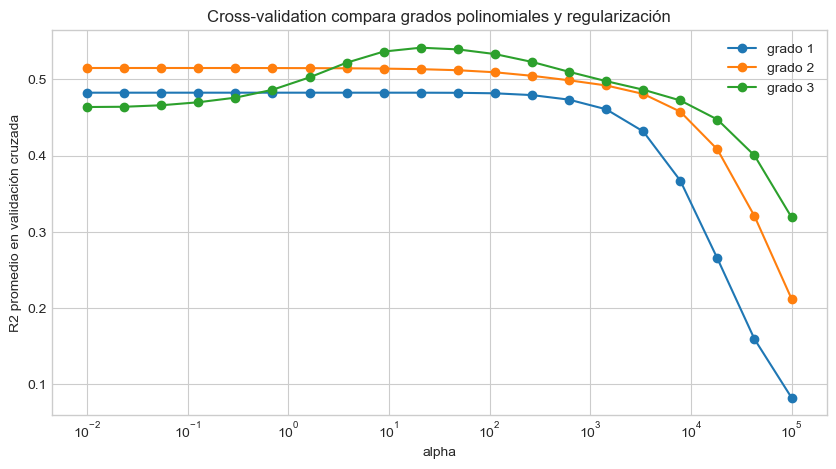

In [16]:
plt.figure(figsize=(10, 5))

for grado_actual in sorted(resumen_cv['grado'].unique()):
    subset = resumen_cv[resumen_cv['grado'] == grado_actual]
    plt.plot(subset['alpha'], subset['R2 validación'], marker='o', label=f'grado {grado_actual}')

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('R2 promedio en validación cruzada')
plt.title('Cross-validation compara grados polinomiales y regularización')
plt.legend()
plt.show()


## Cierre

La intuición final:

- Polinomios agregan flexibilidad.
- Flexibilidad ayuda si la relación no es lineal.
- Demasiada flexibilidad puede sobreajustar.
- Ridge castiga coeficientes grandes para controlar esa flexibilidad.
- Cross-validation ayuda a escoger cuánta flexibilidad y cuánta regularización usar.

Frase útil para recordar:

> Ridge no intenta ganar perfecto en entrenamiento; intenta no perder en datos nuevos.
